In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Loading Train and Test dataset

In [3]:
# First Run this Command to Extract the dataset.zip in the dataset folder
# tar -xf "mandatory-tasks\recommender-systems-cf-to-dlrm\datasets\dataset (tasks 2 and 3).zip" -C "mandatory-tasks\recommender-systems-cf-to-dlrm\datasets"


train_path = "../../datasets/train.csv"
test_path = "../../datasets/test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (40000, 40)
Test shape: (10000, 40)


In [4]:
train.info()
# As u can see some integer_features with missing values are represented by float64 datatype
# Because:- pandas converts a column containing integers + NaN into floating point:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   label                   40000 non-null  int64  
 1   integer_feature_1       32604 non-null  float64
 2   integer_feature_2       36524 non-null  float64
 3   integer_feature_3       30183 non-null  float64
 4   integer_feature_4       24005 non-null  float64
 5   integer_feature_5       24587 non-null  float64
 6   integer_feature_6       36473 non-null  float64
 7   integer_feature_7       38787 non-null  float64
 8   integer_feature_8       40000 non-null  int64  
 9   integer_feature_9       40000 non-null  int64  
 10  integer_feature_10      36473 non-null  float64
 11  integer_feature_11      24587 non-null  float64
 12  integer_feature_12      39889 non-null  float64
 13  integer_feature_13      30183 non-null  float64
 14  categorical_feature_1   38379 non-null

In [5]:
train["label"].value_counts()
# The data is very imbalanced
# Imagine a stupid model which predicts 0(no click) for all the test cases, then its accuracy will be 96.8%


label
0    38720
1     1280
Name: count, dtype: int64

In [6]:
# Percentage Distribution
label_distribution = train["label"].value_counts(normalize=True) * 100
label_distribution

label
0    96.8
1     3.2
Name: proportion, dtype: float64

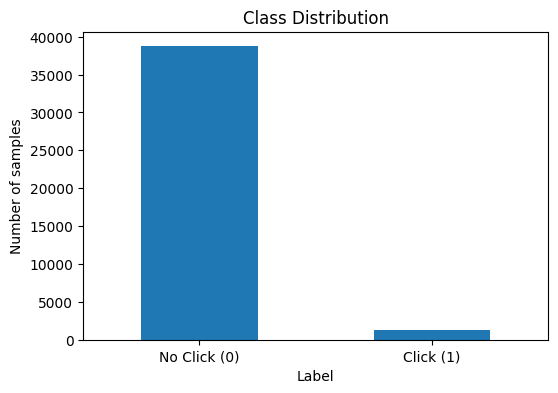

In [7]:
# Visualizing the imbalance

plt.figure(figsize=(6, 4))

train["label"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Label")
plt.ylabel("Number of samples")
plt.title("Class Distribution")
plt.xticks([0, 1], ["No Click (0)", "Click (1)"], rotation=0)

plt.show()

## Inspecting The Integer-Features

In [8]:
# Inspecting The Integer-Features

numerical_features = [col for col in train.columns if col.startswith("integer_feature")]
train[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
integer_feature_1,32604.0,35.691326,545.040254,1.0,3.0,8.0,24.0,65535.0
integer_feature_2,36524.0,407.400641,703.383021,1.0,55.0,177.0,471.0,8000.0
integer_feature_3,30183.0,7.116324,9.264465,0.0,2.0,4.0,9.0,491.0
integer_feature_4,24005.0,146.996626,625.116575,0.0,9.0,32.0,96.0,42898.0
integer_feature_5,24587.0,22.337699,70.349743,1.0,2.0,6.0,17.0,2107.0
integer_feature_6,36473.0,1.606010,6.210465,0.0,0.0,0.0,1.0,288.0
integer_feature_7,38787.0,0.159950,1.646236,0.0,0.0,0.0,0.0,102.0
integer_feature_8,40000.0,115.482225,389.820072,-1.0,1.0,5.0,53.0,8177.0
integer_feature_9,40000.0,10.040550,12.351223,0.0,1.0,5.0,15.0,50.0
integer_feature_10,36473.0,0.267074,0.542083,0.0,0.0,0.0,0.0,7.0


In [9]:
# Finding missing-value percentage for Integer-features

missing_numeric = train[numerical_features].isna().mean() * 100
missing_numeric.sort_values(ascending=False)

integer_feature_4     39.9875
integer_feature_5     38.5325
integer_feature_11    38.5325
integer_feature_13    24.5425
integer_feature_3     24.5425
integer_feature_1     18.4900
integer_feature_6      8.8175
integer_feature_10     8.8175
integer_feature_2      8.6900
integer_feature_7      3.0325
integer_feature_12     0.2775
integer_feature_9      0.0000
integer_feature_8      0.0000
dtype: float64

## Inspecting Categorical Features

In [10]:
categorical_features = [
    col for col in train.columns
    if col.startswith("categorical_feature")
]

print("Number of categorical features:", len(categorical_features))

Number of categorical features: 26


In [11]:
# Finding Missing percentages of Categorical-Features

missing_categorical = train[categorical_features].isna().mean() * 100
missing_categorical.sort_values(ascending=False)

categorical_feature_16    36.3575
categorical_feature_14    36.3575
categorical_feature_23    36.3575
categorical_feature_17    36.3575
categorical_feature_22     4.0525
categorical_feature_21     4.0525
categorical_feature_11     4.0525
categorical_feature_20     4.0525
categorical_feature_1      4.0525
categorical_feature_10     4.0525
categorical_feature_9      0.0000
categorical_feature_8      0.0000
categorical_feature_7      0.0000
categorical_feature_6      0.0000
categorical_feature_4      0.0000
categorical_feature_5      0.0000
categorical_feature_3      0.0000
categorical_feature_2      0.0000
categorical_feature_18     0.0000
categorical_feature_15     0.0000
categorical_feature_12     0.0000
categorical_feature_13     0.0000
categorical_feature_19     0.0000
categorical_feature_24     0.0000
categorical_feature_25     0.0000
categorical_feature_26     0.0000
dtype: float64

In [12]:
# Categorical Cardinity:- How many different categories (unique values) a categorical feature has

cardinality = train[categorical_features].nunique(dropna=False)
cardinality.sort_values(ascending=False)

# As u can see here, Categorical_feature_20 has 13509 unique values, hence one hot encoding would create 13509 columns which is not ideal, hence
# we use embeddings( Will Discuss later)


categorical_feature_20    13509
categorical_feature_1     13191
categorical_feature_22    12629
categorical_feature_10    11585
categorical_feature_21     9003
categorical_feature_12     7723
categorical_feature_11     5569
categorical_feature_23     5095
categorical_feature_3      4968
categorical_feature_5      4253
categorical_feature_2      3757
categorical_feature_24     3504
categorical_feature_7      3111
categorical_feature_15     2025
categorical_feature_4      1851
categorical_feature_14      904
categorical_feature_8       741
categorical_feature_18      341
categorical_feature_16       43
categorical_feature_25       36
categorical_feature_26       24
categorical_feature_9        22
categorical_feature_19       14
categorical_feature_13        9
categorical_feature_17        4
categorical_feature_6         3
dtype: int64

In [13]:
# Just printing first 10 unique values of a feature

for col in categorical_features[:5]:
    print(f"\n{col}")
    print(train[col].dropna().unique()[:10])


categorical_feature_1
['06db406a' '460f9fe5' 'b138ca69' '265366bf' 'b401509b' '62770d79'
 'ad98e872' '3ef4deb3' '1c96e9cc' '2b7872f4']

categorical_feature_2
['929c447a' 'f0192d66' '64649c8d' 'f3a8258c' '4275a45a' 'f7ef23df'
 '3dbb483e' '2c9a47ba' 'cea68cd3' '1db207e6']

categorical_feature_3
['01406fef' '57f2ab3a' '01a0c607' '09d36a86' '7cc4b7b8' 'cf04139b'
 '3c0c8bb3' '2f8b4da4' '3cd7902e' '9a9f1c25']

categorical_feature_4
['4c3b4496' '6faef306' '67ecc871' 'f2463ffb' '79d63b75' '1be9e613'
 '6acb7914' '176bb1e2' '6521d620' '386c49ee']

categorical_feature_5
['c6fc10d3' '27d2607e' 'f1bba148' '664ff944' '74579c57' 'dc635801'
 'f1738f48' 'be06e1c3' '64881166' 'a53c8a84']


## Spliting The Datasats into Training and Validation sets

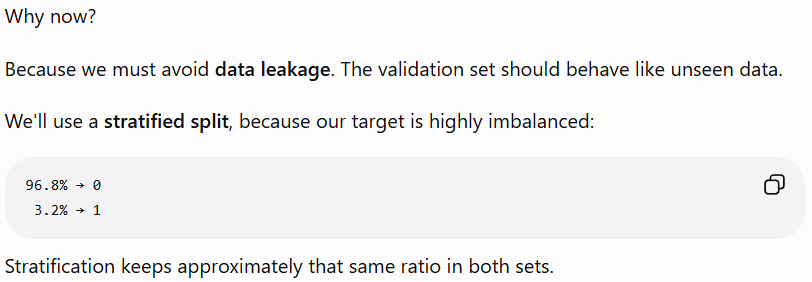

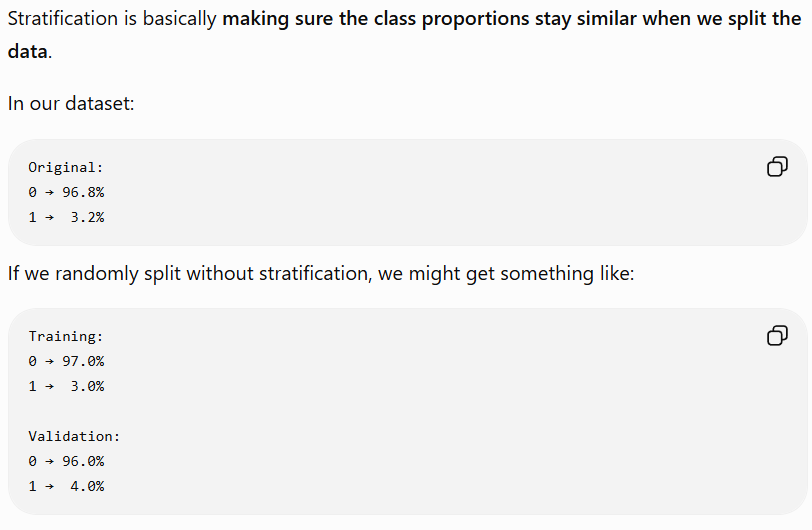

In [14]:
from sklearn.model_selection import train_test_split

X = train.drop(columns="label")
y = train["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("--------------------------------")

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))
print("--------------------------------")

print("\nValidation class distribution:")
print(y_val.value_counts(normalize=True))
print("--------------------------------")


Training: (32000, 39)
Validation: (8000, 39)
--------------------------------

Training class distribution:
label
0    0.968
1    0.032
Name: proportion, dtype: float64
--------------------------------

Validation class distribution:
label
0    0.968
1    0.032
Name: proportion, dtype: float64
--------------------------------


# PREPROCESSING:-

Preprocessing means taking the raw data and transforming it into a form that our machine-learning model can actually work with effectively.

In [15]:
# STEP 1:-  Seprating Numerical Columns

numerical_features  # We already did that

['integer_feature_1',
 'integer_feature_2',
 'integer_feature_3',
 'integer_feature_4',
 'integer_feature_5',
 'integer_feature_6',
 'integer_feature_7',
 'integer_feature_8',
 'integer_feature_9',
 'integer_feature_10',
 'integer_feature_11',
 'integer_feature_12',
 'integer_feature_13']

# Handle missing numerical Values

In [16]:
# Step 2:- Handle missing numerical Values:-
# We will use SimpleImputer function from sklearn.impute to fill all the missing values with Median

from sklearn.impute import SimpleImputer
numeric_imputer = SimpleImputer(strategy="median")



We will calculate medians of training Data an uses those medians in Training, validation and test sets

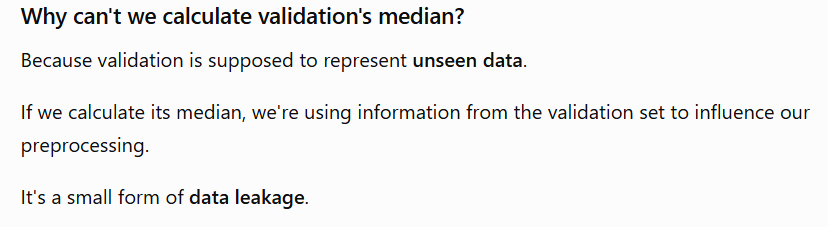

1) Fitting numeric_imputer:- learning median from training data
2) Transform :- Using learnt median to transform / fill NAN's inside validation and test set




In [17]:
X_train_numeric = numeric_imputer.fit_transform(
    X_train[numerical_features]
)
# Does:-
#                        X_train
#                           ↓
#                        FIT → learn the median of each feature
#                           ↓
#                        TRANSFORM → replace missing values using those medians


X_val_numeric = numeric_imputer.transform(
    X_val[numerical_features]
)

#Does:- 
#                        X_val
#                          ↓
#                        use the medians already learned from X_train
#                          ↓
#                        replace missing values


print("Training numerical shape:", X_train_numeric.shape)
print("Validation numerical shape:", X_val_numeric.shape)

Training numerical shape: (32000, 13)
Validation numerical shape: (8000, 13)


# scale the numerical features

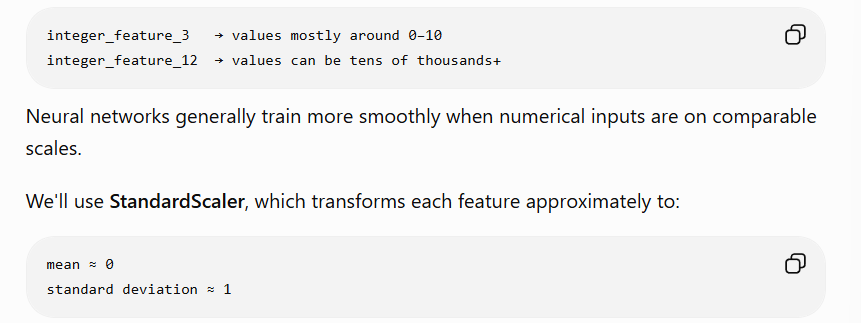

In [18]:
from sklearn.preprocessing import StandardScaler

numeric_scaler = StandardScaler()

X_train_numeric = numeric_scaler.fit_transform(X_train_numeric)
X_val_numeric = numeric_scaler.transform(X_val_numeric)

## Starting With Preprecessing of 26 Categorical Features

We plan on giving each unique value in a Column a ID, which will be used to 
lookup the Embedding vector from Embedding table


STEP 1):- Handle Missing categorical values (By adding __Missing__ )

STEP 2):- Encode The values 

STEP 3):- Create Embeddings for each value of a column

In [19]:

from sklearn.preprocessing import OrdinalEncoder

# 1. Handle missing categorical values
X_train_cat_raw = X_train[categorical_features].fillna("__MISSING__")
X_val_cat_raw = X_val[categorical_features].fillna("__MISSING__")

# 2. Create encoder
categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# 3. Fit ONLY on training data
X_train_cat = categorical_encoder.fit_transform(X_train_cat_raw)

# 4. Apply the same encoder to validation data
X_val_cat = categorical_encoder.transform(X_val_cat_raw)

# 5. Convert to integers
X_train_cat = X_train_cat.astype(np.int64)
X_val_cat = X_val_cat.astype(np.int64)

# 6. Shift everything by +1
#    -1 (unknown) becomes 0
#     0 becomes 1
#     1 becomes 2
#     ...
X_train_cat = X_train_cat + 1
X_val_cat = X_val_cat + 1

print("Training categorical shape:", X_train_cat.shape)
print("Validation categorical shape:", X_val_cat.shape)
print("Minimum training category ID:", X_train_cat.min())
print("Minimum validation category ID:", X_val_cat.min())

Training categorical shape: (32000, 26)
Validation categorical shape: (8000, 26)
Minimum training category ID: 1
Minimum validation category ID: 0


### Starting Worrying about Embeddings

In [20]:
# STEP 1:- Get number of categories for each feature

category_sizes = []

for i, feature in enumerate(categorical_features):
    num_categories = len(categorical_encoder.categories_[i]) + 1
    category_sizes.append(num_categories)

    print(f"{feature}: {num_categories} categories")

categorical_feature_1: 10858 categories
categorical_feature_2: 3349 categories
categorical_feature_3: 4586 categories
categorical_feature_4: 1614 categories
categorical_feature_5: 3643 categories
categorical_feature_6: 4 categories
categorical_feature_7: 2912 categories
categorical_feature_8: 711 categories
categorical_feature_9: 23 categories
categorical_feature_10: 9625 categories
categorical_feature_11: 4772 categories
categorical_feature_12: 6821 categories
categorical_feature_13: 10 categories
categorical_feature_14: 821 categories
categorical_feature_15: 1833 categories
categorical_feature_16: 43 categories
categorical_feature_17: 5 categories
categorical_feature_18: 310 categories
categorical_feature_19: 15 categories
categorical_feature_20: 11112 categories
categorical_feature_21: 7581 categories
categorical_feature_22: 10423 categories
categorical_feature_23: 4362 categories
categorical_feature_24: 3258 categories
categorical_feature_25: 36 categories
categorical_feature_26: 2

## 1) Constant Embedding Dimension

In [21]:
# STEP 5:- Use the same embedding dimension for all categorical features
# For baseline Embeddings we are considering Same Dimensions(32) for all the values of categorical feature
EMBEDDING_DIM = 32

embedding_dims = [EMBEDDING_DIM] * len(categorical_features)

print("Number of categorical features:", len(categorical_features))
print("Embedding dimension:", EMBEDDING_DIM)
print("Total embedding output size:", sum(embedding_dims))
print("Numerical features:", len(numerical_features))
print("Total model input size:", sum(embedding_dims) + len(numerical_features))

Number of categorical features: 26
Embedding dimension: 32
Total embedding output size: 832
Numerical features: 13
Total model input size: 845


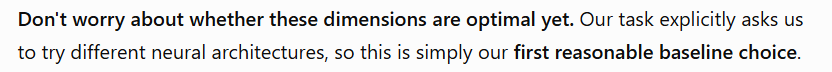

We will have 88752+26= 88778 different Vectors

In [22]:
# STEP 6:- Import TensorFlow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [23]:
# STEP 7:- Create embedding layers

embedding_layers = []

for i, feature in enumerate(categorical_features):
    num_categories = category_sizes[i]
    
    embedding = layers.Embedding(
        input_dim=num_categories,
        output_dim=EMBEDDING_DIM
    )
    
    embedding_layers.append(embedding)

print("Number of embedding layers:", len(embedding_layers))

Number of embedding layers: 26


In [24]:
# STEP 8:- Create inputs for categorical features

categorical_inputs = []

for feature in categorical_features:
    categorical_inputs.append(
        keras.Input(shape=(1,), dtype="int32", name=feature)
    )

print("Number of categorical inputs:", len(categorical_inputs))

Number of categorical inputs: 26


In [25]:
# STEP 9:- Connect each categorical input to its embedding layer

embedded_outputs = []

for i in range(len(categorical_features)):
    embedded = embedding_layers[i](categorical_inputs[i])
    embedded = layers.Flatten()(embedded)
    embedded_outputs.append(embedded)

print("Number of embedded outputs:", len(embedded_outputs))

Number of embedded outputs: 26


In [26]:
# STEP 10:- Create numerical input

numerical_input = keras.Input(
    shape=(len(numerical_features),),
    dtype="float32",
    name="numerical_features"
)

print("Numerical input shape:", numerical_input.shape)

Numerical input shape: (None, 13)


In [27]:
# STEP 11:- Combine categorical embeddings and numerical features

combined_features = layers.Concatenate()(
    embedded_outputs + [numerical_input]
)

combined_features

print("Combined feature shape:", combined_features.shape)


Combined feature shape: (None, 845)


In [28]:
# STEP 12:- Build the vanilla neural network

x = layers.Dense(128, activation="relu")(combined_features)
x = layers.Dropout(0.2)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(1, activation="sigmoid", name="ctr_probability")(x)

print("Output shape:", output.shape)

Output shape: (None, 1)


In [29]:
# STEP 13:- Assemble the vanilla CTR model

model = keras.Model(
    inputs=categorical_inputs + [numerical_input],
    outputs=output,
    name="Vanilla_Neural_CTR"
)

model.summary()

Model: "Vanilla_Neural_CTR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -               

 Total params: 2,956,673 (11.28 MB)

 Trainable params: 2,956,673 (11.28 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# STEP 14:- Compile the model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="roc_auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
        "accuracy"
    ]
)

In [31]:
# STEP 15:- Prepare inputs for the neural network

# 26 categorical inputs
train_inputs = [
    X_train_cat[:, i].astype("int32")
    for i in range(len(categorical_features))
]

val_inputs = [
    X_val_cat[:, i].astype("int32")
    for i in range(len(categorical_features))
]

# 1 numerical input
train_inputs.append(X_train_numeric.astype("float32"))
val_inputs.append(X_val_numeric.astype("float32"))

print("Number of model inputs:", len(train_inputs))
print("First categorical input shape:", train_inputs[0].shape)
print("Numerical input shape:", train_inputs[-1].shape)

Number of model inputs: 27
First categorical input shape: (32000,)
Numerical input shape: (32000, 13)


In [32]:
# STEP 16:- Train the vanilla neural CTR model

history = model.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=10,
    batch_size=256,
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9667 - loss: 0.1705 - pr_auc: 0.0386 - roc_auc: 0.5736 - val_accuracy: 0.9680 - val_loss: 0.1317 - val_pr_auc: 0.0900 - val_roc_auc: 0.7323
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9680 - loss: 0.1185 - pr_auc: 0.1672 - roc_auc: 0.8181 - val_accuracy: 0.9680 - val_loss: 0.1450 - val_pr_auc: 0.0733 - val_roc_auc: 0.6680
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9704 - loss: 0.0774 - pr_auc: 0.5558 - roc_auc: 0.9469 - val_accuracy: 0.9580 - val_loss: 0.1936 - val_pr_auc: 0.0543 - val_roc_auc: 0.6055
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9829 - loss: 0.0489 - pr_auc: 0.7715 - roc_auc: 0.9803 - val_accuracy: 0.9530 - val_loss: 0.2215 - val_pr_auc: 0.0504 - val_roc_auc: 0.5890
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9863 - loss: 0.0377 - pr_auc: 0.8527 - roc_auc: 0.9884 - val_accuracy: 0.9325 - val_loss: 0.2719 - val_pr

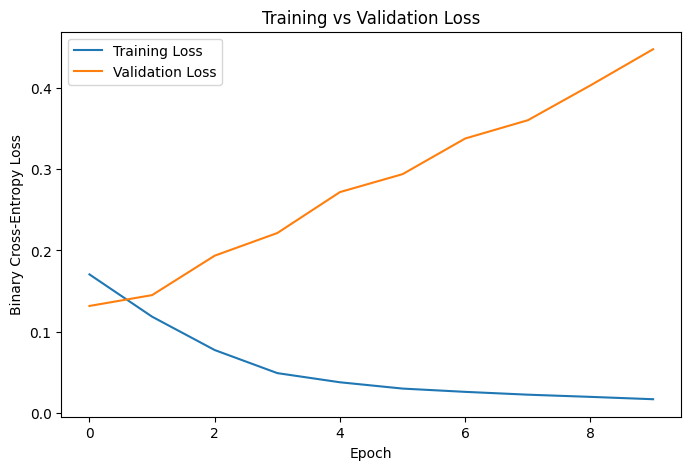

In [33]:
# STEP 17:- Plot training and validation curves

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

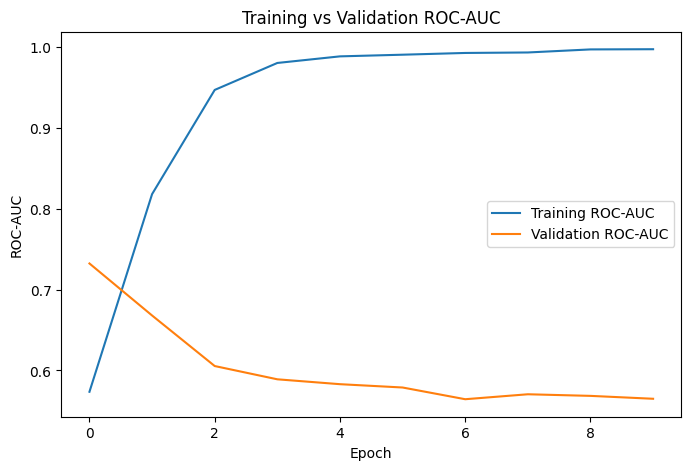

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["roc_auc"], label="Training ROC-AUC")
plt.plot(history.history["val_roc_auc"], label="Validation ROC-AUC")

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Training vs Validation ROC-AUC")
plt.legend()
plt.show()

### The vanilla embedding-based model showed severe overfitting, likely due in part to the high-cardinality categorical features and large number of trainable embedding parameters relative to the dataset size.

We are setting epoch as 1 and fitting the model again, as at epoch 1 Validation score was good

In [37]:
# STEP 18A:- Reset the model before retraining

keras.backend.clear_session()

print("TensorFlow session cleared.")


TensorFlow session cleared.


In [38]:
# STEP 18B:- Rebuild the vanilla model with fresh weights

embedding_layers = []

for i, feature in enumerate(categorical_features):
    embedding = layers.Embedding(
        input_dim=category_sizes[i],
        output_dim=EMBEDDING_DIM
    )
    embedding_layers.append(embedding)

categorical_inputs = []

for feature in categorical_features:
    categorical_inputs.append(
        keras.Input(
            shape=(1,),
            dtype="int32",
            name=feature
        )
    )

embedded_outputs = []

for i in range(len(categorical_features)):
    embedded = embedding_layers[i](categorical_inputs[i])
    embedded = layers.Flatten()(embedded)
    embedded_outputs.append(embedded)

numerical_input = keras.Input(
    shape=(len(numerical_features),),
    dtype="float32",
    name="numerical_features"
)

combined_features = layers.Concatenate()(
    embedded_outputs + [numerical_input]
)

x = layers.Dense(128, activation="relu")(combined_features)
x = layers.Dropout(0.2)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(
    1,
    activation="sigmoid",
    name="ctr_probability"
)(x)

model = keras.Model(
    inputs=categorical_inputs + [numerical_input],
    outputs=output,
    name="Vanilla_Neural_CTR"
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="roc_auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
        "accuracy"
    ]
)

print("Fresh model created.")

Fresh model created.


In [39]:
# STEP 19:- Train the fresh model with early stopping

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

history = model.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=10,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9567 - loss: 0.1836 - pr_auc: 0.0373 - roc_auc: 0.5667 - val_accuracy: 0.9680 - val_loss: 0.1322 - val_pr_auc: 0.0883 - val_roc_auc: 0.7131
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9680 - loss: 0.1208 - pr_auc: 0.1517 - roc_auc: 0.8056 - val_accuracy: 0.9680 - val_loss: 0.1433 - val_pr_auc: 0.0714 - val_roc_auc: 0.6603


the model has substantial capacity, but starts overfitting almost immediately.

In [40]:
# STEP 20:- Generate validation predictions

y_val_prob = model.predict(
    val_inputs,
    batch_size=256,
    verbose=0
).ravel()

print("Number of predictions:", len(y_val_prob))
print("First 10 probabilities:", y_val_prob[:10])

Number of predictions: 8000
First 10 probabilities: [0.0566579  0.00909478 0.01664341 0.03401418 0.0910968  0.01093307
 0.04550857 0.11305714 0.01483065 0.02056829]


In [41]:
# STEP 21:- Evaluate probability-based metrics

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss
)

val_roc_auc = roc_auc_score(y_val, y_val_prob)
val_pr_auc = average_precision_score(y_val, y_val_prob)
val_log_loss = log_loss(y_val, y_val_prob)

print("Validation ROC-AUC :", round(val_roc_auc, 4))
print("Validation PR-AUC  :", round(val_pr_auc, 4))
print("Validation Log Loss:", round(val_log_loss, 4))

Validation ROC-AUC : 0.7168
Validation PR-AUC  : 0.091
Validation Log Loss: 0.1322


In [42]:
# STEP 22:- Compare classification thresholds

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    accuracy = accuracy_score(y_val, y_val_pred)

    print(
        f"Threshold={threshold:.2f} | "
        f"Accuracy={accuracy:.4f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )

Threshold=0.10 | Accuracy=0.9557 | Precision=0.1288 | Recall=0.0664 | F1=0.0876
Threshold=0.20 | Accuracy=0.9679 | Precision=0.0000 | Recall=0.0000 | F1=0.0000
Threshold=0.30 | Accuracy=0.9680 | Precision=0.0000 | Recall=0.0000 | F1=0.0000
Threshold=0.40 | Accuracy=0.9680 | Precision=0.0000 | Recall=0.0000 | F1=0.0000
Threshold=0.50 | Accuracy=0.9680 | Precision=0.0000 | Recall=0.0000 | F1=0.0000


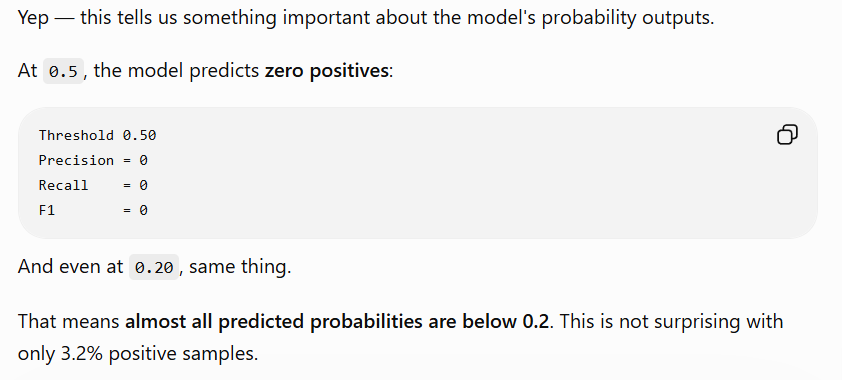

In [43]:
# STEP 22B:- Find threshold that maximizes validation F1

thresholds = np.arange(0.01, 0.201, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", round(best_threshold, 2))
print("Best validation F1:", round(best_f1, 4))

Best threshold: 0.05
Best validation F1: 0.1498


In [44]:
# STEP 23:- Evaluate the selected threshold

selected_threshold = best_threshold

y_val_pred = (y_val_prob >= selected_threshold).astype(int)

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, zero_division=0)
recall = recall_score(y_val, y_val_pred, zero_division=0)
f1 = f1_score(y_val, y_val_pred, zero_division=0)

print("Selected threshold:", round(selected_threshold, 2))
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1       :", round(f1, 4))

Selected threshold: 0.05
Accuracy : 0.8751
Precision: 0.0958
Recall   : 0.3438
F1       : 0.1498


### Baseline Model — Vanilla Neural CTR

A vanilla neural network was implemented as the baseline for CTR prediction. The 13 numerical features were median-imputed and standardized, while the 26 categorical features were converted to integer IDs and represented using separate 32-dimensional embedding tables. The resulting 832 embedding values were concatenated with the 13 numerical features, giving a 845-dimensional input.


### Model Architecture

- **26 categorical features**
  - Each feature → **32D embedding**
  - 26 × 32 = **832 embedding values**
- **13 numerical features**
  - Median imputation → StandardScaler
- Concatenate:
  - 832 embedding values + 13 numerical features
  - **845-dimensional input**
- Dense(128, ReLU)
- Dropout(0.2)
- Dense(64, ReLU)
- Dense(1, Sigmoid)
- Output → **CTR probability**


The model was trained using Adam and binary cross-entropy, with an 80/20 stratified train-validation split. Early stopping was used to control overfitting.

The model showed clear overfitting: training ROC-AUC increased rapidly, while validation ROC-AUC decreased after the first epoch. The best validation performance was obtained at the first epoch.

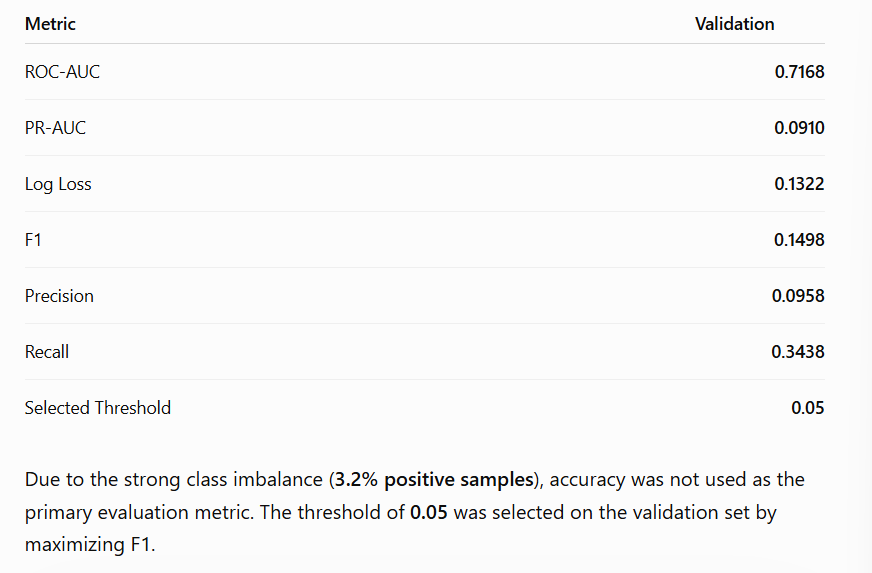


### Experiment 2:- Smaller/ Regularized Model

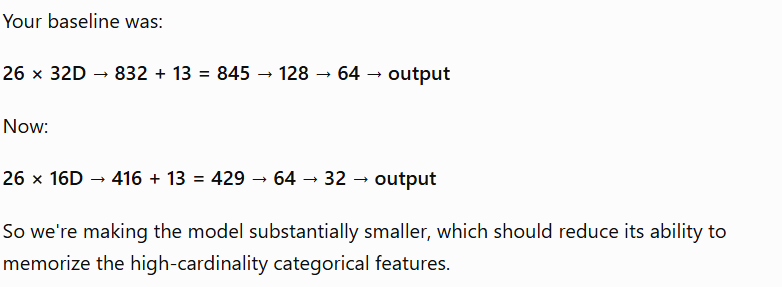

In [45]:
# Clear the previous model
keras.backend.clear_session()

EMBEDDING_DIM = 16

# Categorical inputs
categorical_inputs = []
categorical_embeddings = []

for i, feature in enumerate(categorical_features):
    inp = keras.Input(shape=(), dtype="int32", name=feature)

    emb = keras.layers.Embedding(
        input_dim=category_sizes[i],
        output_dim=EMBEDDING_DIM,
        name=f"{feature}_embedding"
    )(inp)

    emb = keras.layers.Flatten()(emb)

    categorical_inputs.append(inp)
    categorical_embeddings.append(emb)

# Numerical input
numerical_input = keras.Input(
    shape=(len(numerical_features),),
    name="numerical_features"
)

# Combine categorical embeddings + numerical features
combined = keras.layers.Concatenate()(
    categorical_embeddings + [numerical_input]
)

# Smaller neural network
x = keras.layers.Dense(64, activation="relu")(combined)
x = keras.layers.Dropout(0.3)(x)

x = keras.layers.Dense(32, activation="relu")(x)

output = keras.layers.Dense(1, activation="sigmoid")(x)

model_small = keras.Model(
    inputs=categorical_inputs + [numerical_input],
    outputs=output,
    name="Smaller_Neural_CTR"
)

model_small.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="roc_auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
        "accuracy"
    ]
)

model_small.summary()

Model: "Smaller_Neural_CTR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -               

 Total params: 1,449,665 (5.53 MB)

 Trainable params: 1,449,665 (5.53 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

history_small = model_small.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=10,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9569 - loss: 0.1959 - pr_auc: 0.0340 - roc_auc: 0.5418 - val_accuracy: 0.9680 - val_loss: 0.1339 - val_pr_auc: 0.0765 - val_roc_auc: 0.6981
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9680 - loss: 0.1286 - pr_auc: 0.1023 - roc_auc: 0.7471 - val_accuracy: 0.9680 - val_loss: 0.1325 - val_pr_auc: 0.0847 - val_roc_auc: 0.7077
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9680 - loss: 0.0968 - pr_auc: 0.3674 - roc_auc: 0.9076 - val_accuracy: 0.9672 - val_loss: 0.1590 - val_pr_auc: 0.0646 - val_roc_auc: 0.6470


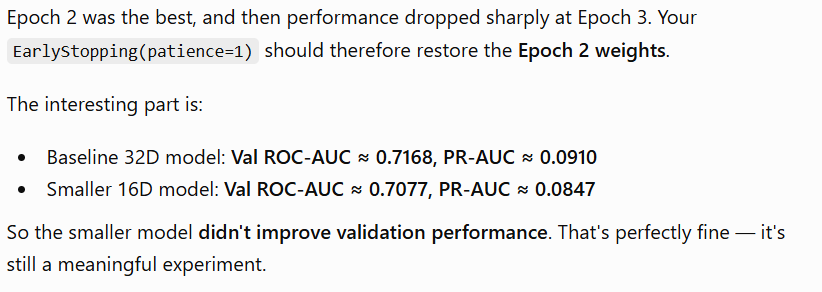

In [47]:
# final restored model's predictions and calculate the same metrics properly,
y_val_prob_small = model_small.predict(
    val_inputs,
    batch_size=256,
    verbose=0
).ravel()

val_roc_auc_small = roc_auc_score(y_val, y_val_prob_small)
val_pr_auc_small = average_precision_score(y_val, y_val_prob_small)
val_log_loss_small = log_loss(y_val, y_val_prob_small)

print("ROC-AUC:", val_roc_auc_small)
print("PR-AUC:", val_pr_auc_small)
print("Log Loss:", val_log_loss_small)

ROC-AUC: 0.7100081010298296
PR-AUC: 0.08696374920110576
Log Loss: 0.13245406717264446


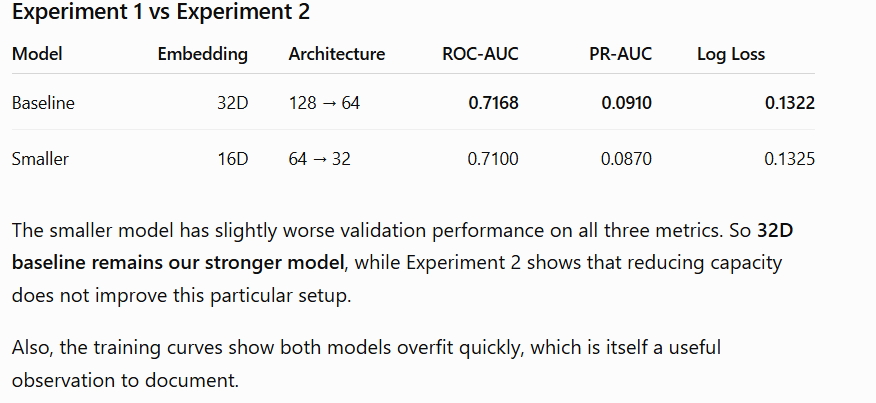

## Experiment 2 — Reduced Model Capacity

To investigate whether the baseline model was over-parameterized, a smaller model was tested using **16-dimensional embeddings** instead of 32D embeddings and a reduced MLP of **64 → 32** neurons. Dropout was increased from 0.2 to 0.3.

The input representation therefore decreased from **845 dimensions to 429 dimensions**.

| Model | Embedding | MLP | ROC-AUC | PR-AUC | Log Loss |
|---|---:|---|---:|---:|---:|
| Baseline | 32D | 128 → 64 | **0.7168** | **0.0910** | **0.1322** |
| Reduced | 16D | 64 → 32 | 0.7100 | 0.0870 | 0.1325 |

The reduced model did not improve validation performance. Both models showed rapid overfitting, with validation performance degrading after only a few epochs. This suggests that simply reducing embedding and MLP dimensions was not sufficient to address overfitting in this dataset.

## Experiment 3 = class-weighted baseline.

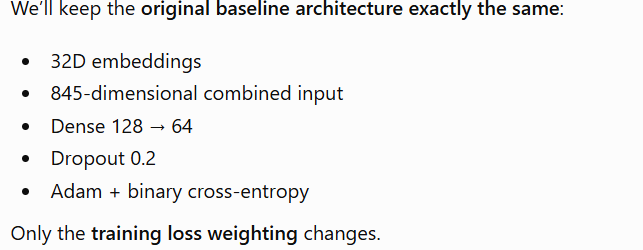

Experiment 3 asks:- 

"Can the same neural network learn the rare click class better if we explicitly penalize mistakes on that class more heavily?"

In [ ]:
# The rarer class gets a larger weight
# Calculate balanced class weights for the imbalanced target

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
print(class_weight_dict)

Class weights:
{np.int64(0): np.float64(0.5165289256198347), np.int64(1): np.float64(15.625)}


In [49]:
keras.backend.clear_session()

EMBEDDING_DIM = 32

categorical_inputs = []
categorical_embeddings = []

for i, feature in enumerate(categorical_features):
    inp = keras.Input(shape=(), dtype="int32", name=feature)

    emb = keras.layers.Embedding(
        input_dim=category_sizes[i],
        output_dim=EMBEDDING_DIM,
        name=f"{feature}_embedding"
    )(inp)

    emb = keras.layers.Flatten()(emb)

    categorical_inputs.append(inp)
    categorical_embeddings.append(emb)

numerical_input = keras.Input(
    shape=(len(numerical_features),),
    name="numerical_features"
)

combined = keras.layers.Concatenate()(
    categorical_embeddings + [numerical_input]
)

x = keras.layers.Dense(128, activation="relu")(combined)
x = keras.layers.Dropout(0.2)(x)

x = keras.layers.Dense(64, activation="relu")(x)

output = keras.layers.Dense(1, activation="sigmoid")(x)

model_weighted = keras.Model(
    inputs=categorical_inputs + [numerical_input],
    outputs=output,
    name="Class_Weighted_Neural_CTR"
)

model_weighted.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="roc_auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
        "accuracy"
    ]
)

model_weighted.summary()

Model: "Class_Weighted_Neural_CTR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None)            │          0 │ -               

 Total params: 2,956,673 (11.28 MB)

 Trainable params: 2,956,673 (11.28 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

history_weighted = model_weighted.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=10,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6243 - loss: 0.6619 - pr_auc: 0.0572 - roc_auc: 0.6528 - val_accuracy: 0.6137 - val_loss: 0.6517 - val_pr_auc: 0.0786 - val_roc_auc: 0.7205
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7607 - loss: 0.4908 - pr_auc: 0.1693 - roc_auc: 0.8418 - val_accuracy: 0.6647 - val_loss: 0.6267 - val_pr_auc: 0.0587 - val_roc_auc: 0.6572
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8826 - loss: 0.2477 - pr_auc: 0.5593 - roc_auc: 0.9620 - val_accuracy: 0.7274 - val_loss: 0.6423 - val_pr_auc: 0.0527 - val_roc_auc: 0.6177


In [51]:
# Evaluate the class-weighted model on the validation set
y_val_prob_weighted = model_weighted.predict(
    val_inputs,
    batch_size=256,
    verbose=0
).ravel()

val_roc_auc_weighted = roc_auc_score(y_val, y_val_prob_weighted)
val_pr_auc_weighted = average_precision_score(y_val, y_val_prob_weighted)
val_log_loss_weighted = log_loss(y_val, y_val_prob_weighted)

print("ROC-AUC:", val_roc_auc_weighted)
print("PR-AUC:", val_pr_auc_weighted)
print("Log Loss:", val_log_loss_weighted)

ROC-AUC: 0.6571665361893079
PR-AUC: 0.06001701714529429
Log Loss: 0.6266551006832262


In [54]:
# Find the threshold that maximizes validation F1 for the weighted model
thresholds = np.arange(0.01, 0.501, 0.01)

best_threshold_weighted = 0
best_f1_weighted = 0

for threshold in thresholds:
    y_pred = (y_val_prob_weighted >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    if f1 > best_f1_weighted:
        best_f1_weighted = f1
        best_threshold_weighted = threshold

y_pred_weighted = (
    y_val_prob_weighted >= best_threshold_weighted
).astype(int)

print("Best threshold:", best_threshold_weighted)
print("Precision:", precision_score(y_val, y_pred_weighted, zero_division=0))
print("Recall:", recall_score(y_val, y_pred_weighted, zero_division=0))
print("F1:", f1_score(y_val, y_pred_weighted, zero_division=0))

Best threshold: 0.5
Precision: 0.054044117647058826
Recall: 0.57421875
F1: 0.09879032258064516


# Experiment 3 — Class-Weighted Training

The dataset is highly imbalanced, with only **3.2% positive samples**. To investigate whether giving greater importance to the minority class could improve CTR prediction, the baseline architecture was trained using balanced class weights.

The positive class received a weight of approximately **15.63**, while the negative class received a weight of approximately **0.52**. The architecture and preprocessing were otherwise kept unchanged.

| Model | ROC-AUC | PR-AUC | Log Loss | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| Baseline | **0.7168** | **0.0910** | **0.1322** | 0.0958 | 0.3438 | **0.1498** |
| Class-Weighted | 0.6572 | 0.0600 | 0.6267 | 0.0540 | **0.5742** | 0.0988 |

The class-weighted model achieved substantially higher recall, detecting more positive samples. However, this came at the cost of much lower precision, resulting in a lower F1 score. ROC-AUC and PR-AUC also decreased compared with the baseline.

Therefore, **class weighting alone was not effective for improving the overall validation performance on this dataset**. It mainly shifted the model toward predicting more positive samples, increasing recall while producing substantially more false positives.

This experiment highlights that handling class imbalance is not simply about maximizing minority-class recall; the resulting precision-recall trade-off must also be considered.

## Experiment 4 = rare-category handling + embedding regularization.

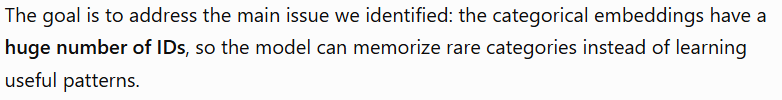
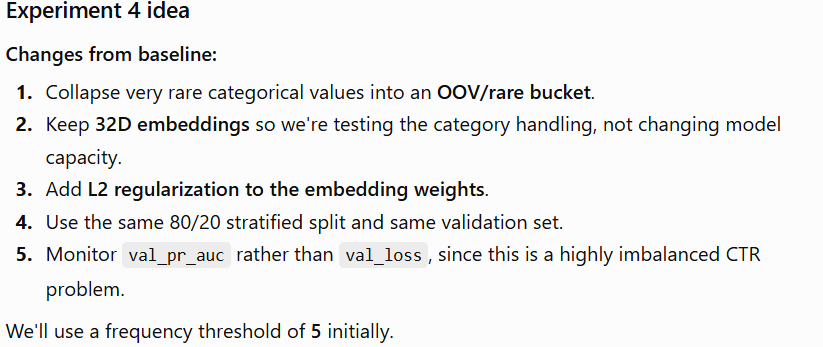

In [56]:
# Define the categorical feature columns for Experiment 4
categorical_cols = [f"categorical_feature_{i}" for i in range(1, 27)]

RARE_THRESHOLD = 5

cat_train_rare = {}
cat_val_rare = {}

for col in categorical_cols:
    counts = X_train[col].value_counts(dropna=False)
    frequent_values = counts[counts >= RARE_THRESHOLD].index

    cat_train_rare[col] = X_train[col].where(
        X_train[col].isin(frequent_values), "__RARE__"
    )

    cat_val_rare[col] = X_val[col].where(
        X_val[col].isin(frequent_values), "__RARE__"
    )

print("Rare-category preprocessing completed.")

Rare-category preprocessing completed.


In [58]:
# Encode rare-collapsed categories into embedding IDs
cat_train_encoded = {}
cat_val_encoded = {}
embedding_input_dims = {}

for col in categorical_cols:
    values = cat_train_rare[col].astype(str).unique()

    # Create an ID for each training category
    mapping = {value: idx + 1 for idx, value in enumerate(values)}

    cat_train_encoded[col] = (
        cat_train_rare[col].astype(str).map(mapping).fillna(0).astype("int32")
    )

    cat_val_encoded[col] = (
        cat_val_rare[col].astype(str).map(mapping).fillna(0).astype("int32")
    )

    # +1 reserves ID 0 for unknown/rare categories
    embedding_input_dims[col] = len(mapping) + 1

print("Categorical encoding completed.")
print("Total categorical features:", len(categorical_cols))

Categorical encoding completed.
Total categorical features: 26


In [59]:
# Prepare scaled numeric features for Experiment 4
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

numeric_cols = [f"integer_feature_{i}" for i in range(1, 14)]

num_imputer = SimpleImputer(strategy="median")
num_scaler = StandardScaler()

X_train_num = num_imputer.fit_transform(X_train[numeric_cols])
X_val_num = num_imputer.transform(X_val[numeric_cols])

X_train_num = num_scaler.fit_transform(X_train_num).astype("float32")
X_val_num = num_scaler.transform(X_val_num).astype("float32")

print("Numeric features:", X_train_num.shape[1])
print("Training numeric shape:", X_train_num.shape)
print("Validation numeric shape:", X_val_num.shape)

Numeric features: 13
Training numeric shape: (32000, 13)
Validation numeric shape: (8000, 13)


In [60]:
# Build the rare-category model with embedding L2 regularization
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers

embedding_dim = 32
l2_strength = 1e-6

cat_inputs = []
cat_embeddings = []

for col in categorical_cols:
    inp = layers.Input(shape=(1,), name=col)
    emb = layers.Embedding(
        input_dim=embedding_input_dims[col],
        output_dim=embedding_dim,
        embeddings_regularizer=regularizers.l2(l2_strength),
        name=f"{col}_embedding"
    )(inp)

    emb = layers.Flatten()(emb)

    cat_inputs.append(inp)
    cat_embeddings.append(emb)

num_input = layers.Input(
    shape=(len(numeric_cols),),
    name="numeric_features"
)

combined = layers.Concatenate()(
    cat_embeddings + [num_input]
)

x = layers.Dense(128, activation="relu")(combined)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(1, activation="sigmoid")(x)

model_exp4 = Model(
    inputs=cat_inputs + [num_input],
    outputs=output
)

model_exp4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        "accuracy"
    ]
)

model_exp4.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -               

 Total params: 434,049 (1.66 MB)

 Trainable params: 434,049 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Train Experiment 4 with PR-AUC based early stopping
train_inputs = [
    cat_train_encoded[col].to_numpy().reshape(-1, 1)
    for col in categorical_cols
]

val_inputs = [
    cat_val_encoded[col].to_numpy().reshape(-1, 1)
    for col in categorical_cols
]

train_inputs.append(X_train_num)
val_inputs.append(X_val_num)

early_stopping_exp4 = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=2,
    restore_best_weights=True
)

history_exp4 = model_exp4.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=10,
    batch_size=256,
    callbacks=[early_stopping_exp4],
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9471 - loss: 0.2584 - pr_auc: 0.0327 - roc_auc: 0.5153 - val_accuracy: 0.9680 - val_loss: 0.1378 - val_pr_auc: 0.0590 - val_roc_auc: 0.6494
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9680 - loss: 0.1385 - pr_auc: 0.0569 - roc_auc: 0.6432 - val_accuracy: 0.9680 - val_loss: 0.1332 - val_pr_auc: 0.0790 - val_roc_auc: 0.7091
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9680 - loss: 0.1305 - pr_auc: 0.0942 - roc_auc: 0.7318 - val_accuracy: 0.9680 - val_loss: 0.1321 - val_pr_auc: 0.0852 - val_roc_auc: 0.7203
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9680 - loss: 0.1208 - pr_auc: 0.1483 - roc_auc: 0.8135 - val_accuracy: 0.9680 - val_loss: 0.1337 - val_pr_auc: 0.0829 - val_roc_auc: 0.7110
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9680 - loss: 0.1104 - pr_auc: 0.2185 - roc_auc: 0.8659 - val_accuracy: 0.9680 - val_loss: 0.1407 - val_pr_auc

In [62]:
# Evaluate Experiment 4 on the validation set
exp4_results = model_exp4.evaluate(
    val_inputs,
    y_val,
    verbose=0,
    return_dict=True
)

print("Experiment 4 validation metrics:")
for name, value in exp4_results.items():
    print(f"{name}: {value:.4f}")

Experiment 4 validation metrics:
accuracy: 0.9680
loss: 0.1321
pr_auc: 0.0852
roc_auc: 0.7203


In [63]:
# Find the threshold that maximizes validation F1
from sklearn.metrics import precision_score, recall_score, f1_score

exp4_pred = model_exp4.predict(val_inputs, verbose=0).ravel()

thresholds = np.arange(0.01, 0.51, 0.01)
threshold_results = []

for threshold in thresholds:
    pred_labels = (exp4_pred >= threshold).astype(int)

    precision = precision_score(y_val, pred_labels, zero_division=0)
    recall = recall_score(y_val, pred_labels, zero_division=0)
    f1 = f1_score(y_val, pred_labels, zero_division=0)

    threshold_results.append((threshold, precision, recall, f1))

best_exp4 = max(threshold_results, key=lambda x: x[3])

print(f"Best threshold: {best_exp4[0]:.2f}")
print(f"Precision: {best_exp4[1]:.4f}")
print(f"Recall: {best_exp4[2]:.4f}")
print(f"F1: {best_exp4[3]:.4f}")

Best threshold: 0.06
Precision: 0.1166
Recall: 0.2969
F1: 0.1674


## Experiment 4 — Rare-Category Handling + Embedding Regularization

Rare categorical values occurring fewer than 5 times were grouped into a shared `__RARE__` bucket. The model retained 32-dimensional embeddings, added L2 regularization to the embedding layers, used a lower learning rate of 3e-4, and selected the best model using validation PR-AUC.

| Metric | Baseline | Experiment 4 |
|---|---:|---:|
| ROC-AUC | 0.7168 | 0.7203 |
| PR-AUC | 0.0910 | 0.0852 |
| Log loss | 0.1322 | 0.1321 |
| Precision | 0.0958 | 0.1166 |
| Recall | 0.3438 | 0.2969 |
| F1 | 0.1498 | 0.1674 |

Experiment 4 produced a slightly higher ROC-AUC and lower log loss, while PR-AUC decreased slightly. At the F1-optimized threshold of 0.06, precision and F1 improved, although recall decreased.

Overall, this combined regularization approach did not clearly improve the ranking metrics over the baseline, but it provided a modest improvement in threshold-based F1. The small metric differences should not be overinterpreted because they come from a single validation split with relatively few positive examples.

## Experiment 5

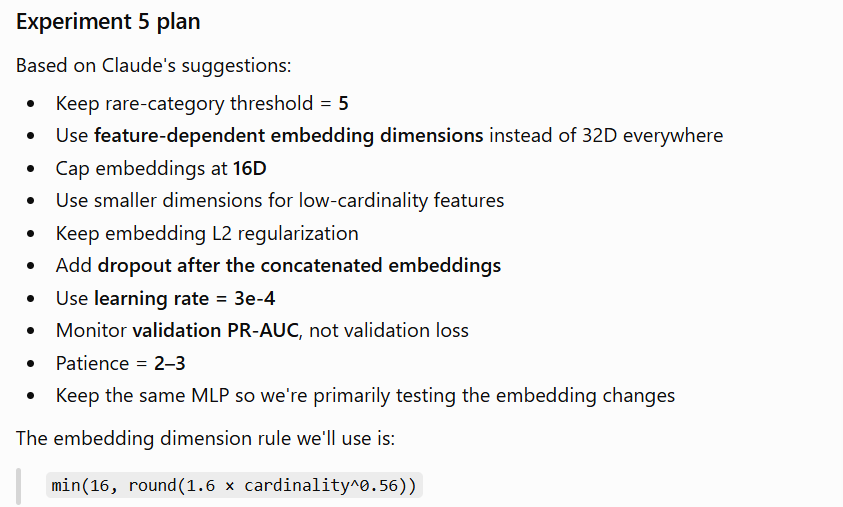

In [64]:
# Calculate feature-specific embedding dimensions
embedding_dims = {}

for col in categorical_cols:
    cardinality = embedding_input_dims[col] - 1

    dim = min(
        16,
        max(4, round(1.6 * (cardinality ** 0.56)))
    )

    embedding_dims[col] = dim

for col in categorical_cols:
    print(f"{col}: cardinality={embedding_input_dims[col] - 1}, embedding_dim={embedding_dims[col]}")

categorical_feature_1: cardinality=329, embedding_dim=16
categorical_feature_2: cardinality=770, embedding_dim=16
categorical_feature_3: cardinality=1290, embedding_dim=16
categorical_feature_4: cardinality=237, embedding_dim=16
categorical_feature_5: cardinality=349, embedding_dim=16
categorical_feature_6: cardinality=3, embedding_dim=4
categorical_feature_7: cardinality=1020, embedding_dim=16
categorical_feature_8: cardinality=351, embedding_dim=16
categorical_feature_9: cardinality=19, embedding_dim=8
categorical_feature_10: cardinality=398, embedding_dim=16
categorical_feature_11: cardinality=464, embedding_dim=16
categorical_feature_12: cardinality=1096, embedding_dim=16
categorical_feature_13: cardinality=9, embedding_dim=5
categorical_feature_14: cardinality=212, embedding_dim=16
categorical_feature_15: cardinality=571, embedding_dim=16
categorical_feature_16: cardinality=23, embedding_dim=9
categorical_feature_17: cardinality=4, embedding_dim=4
categorical_feature_18: cardinali

In [65]:
# Build Experiment 5 with feature-specific embeddings and stronger regularization
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

exp5_inputs = []
exp5_embeddings = []

for col in categorical_cols:
    input_layer = layers.Input(
        shape=(1,),
        dtype="int32",
        name=f"{col}_input"
    )

    embedding_layer = layers.Embedding(
        input_dim=embedding_input_dims[col],
        output_dim=embedding_dims[col],
        embeddings_regularizer=regularizers.l2(1e-5),
        name=f"{col}_embedding"
    )

    embedded = embedding_layer(input_layer)
    embedded = layers.Flatten()(embedded)

    exp5_inputs.append(input_layer)
    exp5_embeddings.append(embedded)

numeric_input_exp5 = layers.Input(
    shape=(X_train_num.shape[1],),
    dtype="float32",
    name="numeric_input"
)

exp5_inputs.append(numeric_input_exp5)

combined_exp5 = layers.Concatenate()(
    exp5_embeddings + [numeric_input_exp5]
)

# Regularize the combined representation before the MLP
x = layers.Dropout(0.2)(combined_exp5)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

output_exp5 = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model_exp5 = models.Model(
    inputs=exp5_inputs,
    outputs=output_exp5
)

model_exp5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

model_exp5.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_featur… │ (None, 1)         │          0 │ -               

 Total params: 211,755 (827.17 KB)

 Trainable params: 211,755 (827.17 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# Train Experiment 5 with PR-AUC based early stopping
train_inputs_exp5 = [
    cat_train_encoded[col].to_numpy().reshape(-1, 1)
    for col in categorical_cols
]

val_inputs_exp5 = [
    cat_val_encoded[col].to_numpy().reshape(-1, 1)
    for col in categorical_cols
]

train_inputs_exp5.append(X_train_num)
val_inputs_exp5.append(X_val_num)

early_stopping_exp5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=2,
    restore_best_weights=True
)

history_exp5 = model_exp5.fit(
    train_inputs_exp5,
    y_train,
    validation_data=(val_inputs_exp5, y_val),
    epochs=10,
    batch_size=256,
    callbacks=[early_stopping_exp5],
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9395 - loss: 0.2897 - pr_auc: 0.0319 - roc_auc: 0.5091 - val_accuracy: 0.9680 - val_loss: 0.1405 - val_pr_auc: 0.0519 - val_roc_auc: 0.6277
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9680 - loss: 0.1445 - pr_auc: 0.0505 - roc_auc: 0.6027 - val_accuracy: 0.9680 - val_loss: 0.1369 - val_pr_auc: 0.0642 - val_roc_auc: 0.6723
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9680 - loss: 0.1388 - pr_auc: 0.0686 - roc_auc: 0.6647 - val_accuracy: 0.9680 - val_loss: 0.1351 - val_pr_auc: 0.0718 - val_roc_auc: 0.6957
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9680 - loss: 0.1327 - pr_auc: 0.0882 - roc_auc: 0.7273 - val_accuracy: 0.9680 - val_loss: 0.1344 - val_pr_auc: 0.0756 - val_roc_auc: 0.7035
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9680 - loss: 0.1246 - pr_auc: 0.1282 - roc_auc: 0.7962 - val_accuracy: 0.9680 - val_loss: 0.1359 - val_pr_auc

In [67]:
# Evaluate Experiment 5 on the validation set
exp5_results = model_exp5.evaluate(
    val_inputs_exp5,
    y_val,
    verbose=0,
    return_dict=True
)

print("Experiment 5 validation metrics:")
for name, value in exp5_results.items():
    print(f"{name}: {value:.4f}")

Experiment 5 validation metrics:
accuracy: 0.9680
loss: 0.1359
pr_auc: 0.0759
roc_auc: 0.6999


In [68]:

# Find the validation threshold with the best F1 score
from sklearn.metrics import precision_score, recall_score, f1_score

exp5_pred = model_exp5.predict(
    val_inputs_exp5,
    verbose=0
).ravel()

thresholds = np.arange(0.01, 0.51, 0.01)
threshold_results_exp5 = []

for threshold in thresholds:
    pred_labels = (exp5_pred >= threshold).astype(int)

    precision = precision_score(y_val, pred_labels, zero_division=0)
    recall = recall_score(y_val, pred_labels, zero_division=0)
    f1 = f1_score(y_val, pred_labels, zero_division=0)

    threshold_results_exp5.append(
        (threshold, precision, recall, f1)
    )

best_exp5 = max(
    threshold_results_exp5,
    key=lambda x: x[3]
)

print(f"Best threshold: {best_exp5[0]:.2f}")
print(f"Precision: {best_exp5[1]:.4f}")
print(f"Recall: {best_exp5[2]:.4f}")
print(f"F1: {best_exp5[3]:.4f}")

Best threshold: 0.07
Precision: 0.0990
Recall: 0.2773
F1: 0.1459


## Experiment 5 — Feature-Specific Embedding Dimensions

To reduce the large embedding parameter count, each categorical feature was assigned an embedding dimension based on its cardinality, capped at 16 dimensions. Small-cardinality features received smaller embeddings. Stronger embedding L2 regularization (1e-5) and dropout on the combined representation were also used.

The resulting categorical + numerical representation was reduced from 845 dimensions in the baseline to 356 dimensions.

| Metric | Baseline | Experiment 5 |
|---|---:|---:|
| ROC-AUC | 0.7168 | 0.6999 |
| PR-AUC | 0.0910 | 0.0759 |
| Log loss | 0.1322 | 0.1359 |
| Precision | 0.0958 | 0.0990 |
| Recall | 0.3438 | 0.2773 |
| F1 | 0.1498 | 0.1459 |

The reduced embedding representation substantially lowers model capacity, but validation ROC-AUC and PR-AUC decreased compared with the baseline. The threshold-optimized F1 also decreased slightly.

This suggests that the aggressive reduction in embedding capacity removed useful information from the categorical representations. Therefore, reducing embedding dimensions alone did not improve validation performance, despite making the model more compact.

# Overall Analysis of Vanilla Neural CTR Experiments

The five experiments progressively investigated model capacity, class imbalance, categorical preprocessing, and embedding regularization.

| Experiment | Main Change | ROC-AUC | PR-AUC | Log Loss | Precision | Recall | F1 |
|---|---|---:|---:|---:|---:|---:|---:|
| Baseline | 32D embeddings + 128→64 MLP | 0.7168 | **0.0910** | 0.1322 | 0.0958 | 0.3438 | 0.1498 |
| Exp 2 | Reduced embeddings + smaller MLP | 0.7100 | 0.0870 | 0.1325 | 0.1288 | 0.0664 | 0.0876 |
| Exp 3 | Class-weighted training | 0.6572 | 0.0600 | 0.6267 | 0.0540 | **0.5742** | 0.0988 |
| Exp 4 | Rare-category handling + embedding L2 regularization | **0.7203** | 0.0852 | **0.1321** | **0.1166** | 0.2969 | **0.1674** |
| Exp 5 | Feature-specific smaller embeddings + stronger regularization | 0.6999 | 0.0759 | 0.1359 | 0.0990 | 0.2773 | 0.1459 |

### Analysis

**Baseline:**  
The baseline established the reference performance using 32-dimensional embeddings for all categorical features and a 128→64 MLP. It achieved a ROC-AUC of 0.7168 and the highest PR-AUC of 0.0910 among the five vanilla models.

**Experiment 2 — Reduced Model Capacity:**  
Reducing the embedding size to 16 dimensions and shrinking the MLP resulted in slightly lower ROC-AUC and PR-AUC. This suggests that simply reducing model capacity did not solve the generalization problem.

**Experiment 3 — Class Weighting:**  
Class weighting substantially increased recall but reduced precision and both ranking metrics. The very large increase in validation log loss also indicates that the resulting probability estimates were poorly calibrated. Class weighting therefore changed the prediction behaviour toward detecting more positive examples rather than improving overall ranking quality.

**Experiment 4 — Rare Categories + Embedding Regularization:**  
Rare categorical values were grouped into a shared `__RARE__` bucket, embedding L2 regularization was added, and training used a lower learning rate with PR-AUC based early stopping. ROC-AUC increased slightly to 0.7203 and log loss decreased slightly to 0.1321. The F1 score also increased to 0.1674 at a threshold of 0.06. However, PR-AUC decreased slightly compared with the baseline.

**Experiment 5 — Feature-Specific Embeddings:**  
Embedding dimensions were selected according to feature cardinality and capped at 16 dimensions, reducing the combined representation from 845 to 356 dimensions. Stronger embedding regularization and dropout were also used. Although this substantially reduced model capacity, ROC-AUC and PR-AUC decreased to 0.6999 and 0.0759 respectively. This suggests that the more aggressive embedding compression removed useful categorical information.

### Key Findings

1. The **baseline provided the highest PR-AUC (0.0910)** among the five experiments.
2. Experiment 4 achieved the **highest ROC-AUC (0.7203)** and the **lowest log loss (0.1321)**.
3. Experiment 4 also achieved the highest threshold-optimized **F1 score (0.1674)**.
4. Class weighting increased recall substantially, but this came with lower precision and weaker ranking metrics.
5. Reducing embedding capacity alone did not improve validation performance.
6. The results suggest that the main limitation is not simply model size. The next experiment therefore investigates whether **explicit feature interactions** can improve CTR prediction without relying only on a larger MLP.

In [69]:
# Store validation metrics from all five experiments for comparison
import pandas as pd
import matplotlib.pyplot as plt

experiment_metrics = pd.DataFrame({
    "Experiment": [
        "Baseline",
        "Experiment 2",
        "Experiment 3",
        "Experiment 4",
        "Experiment 5"
    ],
    "ROC-AUC": [0.7168, 0.7100, 0.6572, 0.7203, 0.6999],
    "PR-AUC": [0.0910, 0.0870, 0.0600, 0.0852, 0.0759],
    "Log Loss": [0.1322, 0.1325, 0.6267, 0.1321, 0.1359],
    "Precision": [0.0958, 0.1288, 0.0540, 0.1166, 0.0990],
    "Recall": [0.3438, 0.0664, 0.5742, 0.2969, 0.2773],
    "F1": [0.1498, 0.0876, 0.0988, 0.1674, 0.1459]
})

experiment_metrics

,Experiment,ROC-AUC,PR-AUC,Log Loss,Precision,Recall,F1
0,Baseline,0.7168,0.0910,0.1322,0.0958,0.3438,0.1498
1,Experiment 2,0.7100,0.0870,0.1325,0.1288,0.0664,0.0876
2,Experiment 3,0.6572,0.0600,0.6267,0.0540,0.5742,0.0988
3,Experiment 4,0.7203,0.0852,0.1321,0.1166,0.2969,0.1674
4,Experiment 5,0.6999,0.0759,0.1359,0.0990,0.2773,0.1459


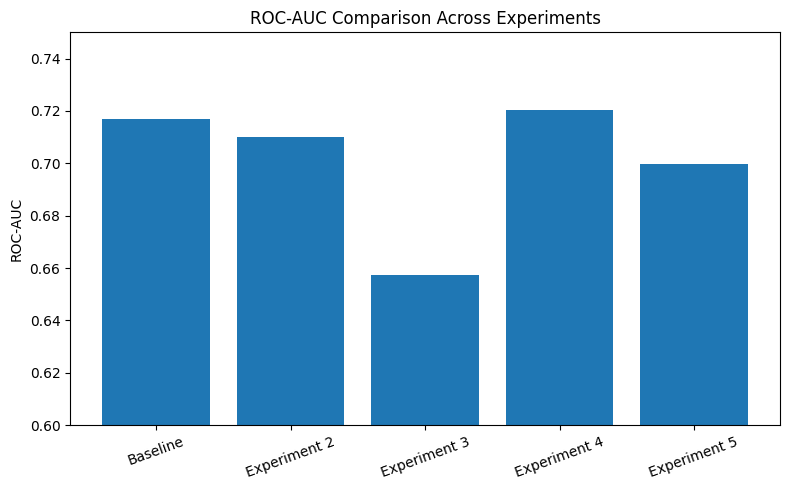

In [70]:
# Compare ROC-AUC across all five experiments
plt.figure(figsize=(8, 5))

plt.bar(
    experiment_metrics["Experiment"],
    experiment_metrics["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison Across Experiments")
plt.xticks(rotation=20)
plt.ylim(0.6, 0.75)
plt.tight_layout()
plt.show()

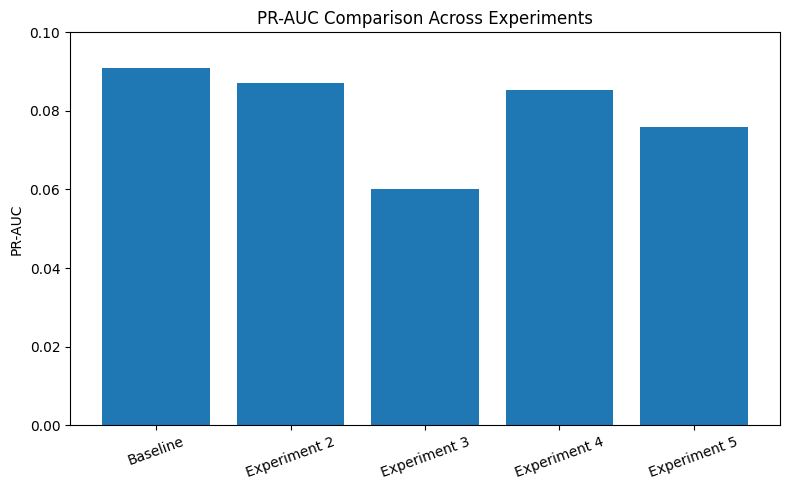

In [71]:
# Compare PR-AUC across all five experiments
plt.figure(figsize=(8, 5))

plt.bar(
    experiment_metrics["Experiment"],
    experiment_metrics["PR-AUC"]
)

plt.ylabel("PR-AUC")
plt.title("PR-AUC Comparison Across Experiments")
plt.xticks(rotation=20)
plt.ylim(0, 0.10)
plt.tight_layout()
plt.show()

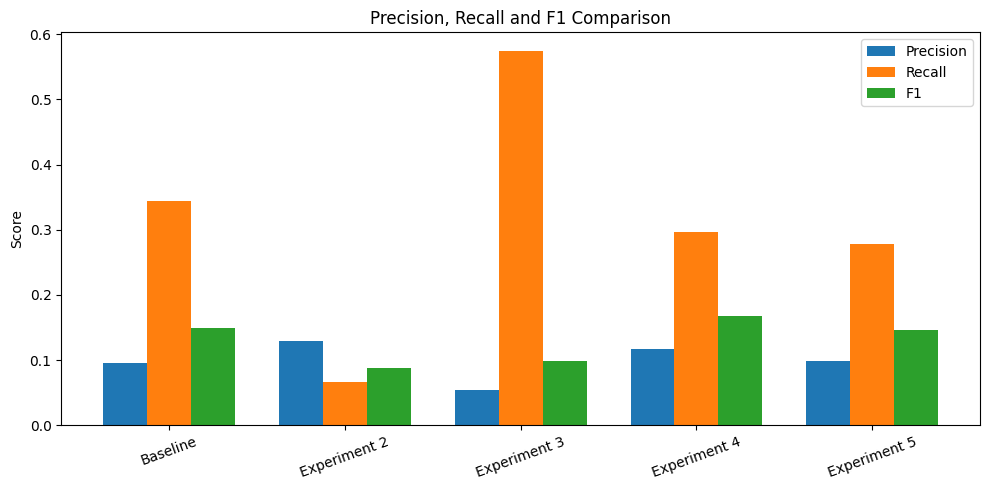

In [72]:
# Compare threshold-based precision, recall and F1 across experiments
x = range(len(experiment_metrics))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    [i - width for i in x],
    experiment_metrics["Precision"],
    width=width,
    label="Precision"
)

plt.bar(
    x,
    experiment_metrics["Recall"],
    width=width,
    label="Recall"
)

plt.bar(
    [i + width for i in x],
    experiment_metrics["F1"],
    width=width,
    label="F1"
)

plt.xticks(x, experiment_metrics["Experiment"], rotation=20)
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Comparison")
plt.legend()
plt.tight_layout()
plt.show()

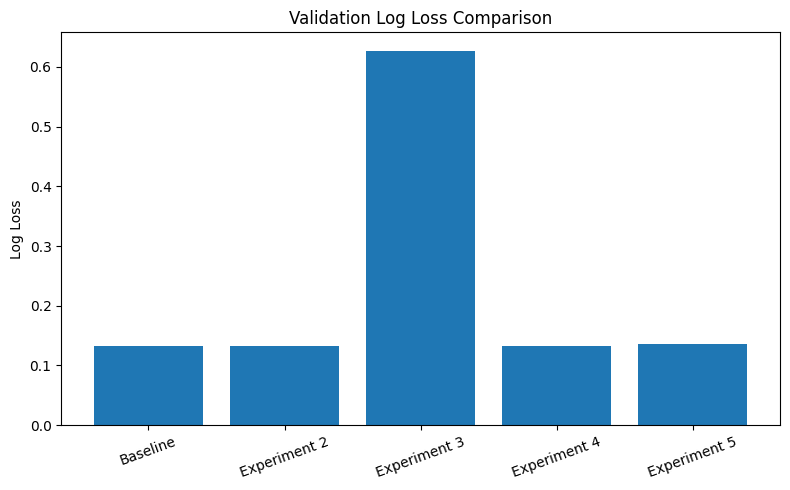

In [73]:
# Compare validation log loss across experiments
plt.figure(figsize=(8, 5))

plt.bar(
    experiment_metrics["Experiment"],
    experiment_metrics["Log Loss"]
)

plt.ylabel("Log Loss")
plt.title("Validation Log Loss Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Deep & Cross Network (DCN)

Deep & Cross Network (DCN) was introduced for CTR prediction to learn feature interactions more efficiently. A standard DNN can learn feature interactions implicitly through its hidden layers, but it may not efficiently learn useful low-degree cross features.

DCN combines two components:

- **Deep Network:** learns complex and highly nonlinear feature interactions implicitly.
- **Cross Network:** explicitly learns bounded-degree feature interactions without requiring manual feature engineering.

The model first converts categorical features into embeddings and stacks them with the normalized numerical features to form the input vector \(x_0\).

The Cross Network applies successive cross layers:

\[
x_{l+1}=x_0(x_l^T w_l)+b_l+x_l
\]

Each additional cross layer increases the maximum degree of the feature interactions by one. The cross network is also parameter-efficient because its number of parameters grows linearly with the input dimension.

The outputs of the Cross Network and Deep Network are concatenated and passed to the final prediction layer:

```text
Embeddings + Numerical Features
              ↓
             x₀
          ↙       ↘
     Cross Net    Deep Net
          ↓       ↓
          └───┬───┘
              ↓
       Combination Layer
              ↓
          CTR Prediction

In [74]:
# Build the shared embedding and stacking input for the DCN
import tensorflow as tf
from tensorflow.keras import layers

dcn_inputs = []
dcn_embeddings = []

for col in categorical_cols:
    input_layer = layers.Input(
        shape=(1,),
        dtype="int32",
        name=f"dcn_{col}_input"
    )

    embedding_layer = layers.Embedding(
        input_dim=embedding_input_dims[col],
        output_dim=32,
        name=f"dcn_{col}_embedding"
    )

    embedded = embedding_layer(input_layer)
    embedded = layers.Flatten()(embedded)

    dcn_inputs.append(input_layer)
    dcn_embeddings.append(embedded)

dcn_numeric_input = layers.Input(
    shape=(X_train_num.shape[1],),
    dtype="float32",
    name="dcn_numeric_input"
)

dcn_inputs.append(dcn_numeric_input)

x0 = layers.Concatenate()(
    dcn_embeddings + [dcn_numeric_input]
)

print("DCN input dimension:", x0.shape[-1])

DCN input dimension: 845


In [75]:
# Define the DCN cross layer from the paper
class CrossLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        dimension = input_shape[0][-1]

        self.w = self.add_weight(
            name="cross_weight",
            shape=(dimension,),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="cross_bias",
            shape=(dimension,),
            initializer="zeros",
            trainable=True
        )

    def call(self, inputs):
        x0, xl = inputs

        cross_term = tf.reduce_sum(
            xl * self.w,
            axis=1,
            keepdims=True
        )

        return x0 * cross_term + self.b + xl

In [76]:
# Build a two-layer cross network
cross_1 = CrossLayer(name="cross_layer_1")(
    [x0, x0]
)

cross_2 = CrossLayer(name="cross_layer_2")(
    [x0, cross_1]
)

print("Cross network output dimension:", cross_2.shape[-1])

Cross network output dimension: 845


In [77]:
# Build the deep network branch of DCN
deep = layers.Dense(
    128,
    activation="relu",
    name="dcn_deep_dense_128"
)(x0)

deep = layers.Dropout(
    0.2,
    name="dcn_deep_dropout_1"
)(deep)

deep = layers.Dense(
    64,
    activation="relu",
    name="dcn_deep_dense_64"
)(deep)

deep = layers.Dropout(
    0.2,
    name="dcn_deep_dropout_2"
)(deep)

print("Deep network output dimension:", deep.shape[-1])

Deep network output dimension: 64


In [78]:
# Combine the cross and deep branches for final CTR prediction
combined_dcn = layers.Concatenate(
    name="dcn_combination"
)([cross_2, deep])

dcn_output = layers.Dense(
    1,
    activation="sigmoid",
    name="dcn_output"
)(combined_dcn)

model_dcn = tf.keras.Model(
    inputs=dcn_inputs,
    outputs=dcn_output,
    name="DeepCrossNetwork"
)

model_dcn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

model_dcn.summary()

Model: "DeepCrossNetwork"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -               

 Total params: 438,274 (1.67 MB)

 Trainable params: 438,274 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# Train the Deep & Cross Network with PR-AUC based early stopping
early_stopping_dcn = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=2,
    restore_best_weights=True
)

history_dcn = model_dcn.fit(
    train_inputs_exp5,
    y_train,
    validation_data=(val_inputs_exp5, y_val),
    epochs=10,
    batch_size=256,
    callbacks=[early_stopping_dcn],
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9637 - loss: 0.1876 - pr_auc: 0.0349 - roc_auc: 0.5429 - val_accuracy: 0.9680 - val_loss: 0.1374 - val_pr_auc: 0.0584 - val_roc_auc: 0.6484
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9680 - loss: 0.1350 - pr_auc: 0.0698 - roc_auc: 0.6830 - val_accuracy: 0.9680 - val_loss: 0.1330 - val_pr_auc: 0.0786 - val_roc_auc: 0.7099
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9680 - loss: 0.1269 - pr_auc: 0.1061 - roc_auc: 0.7789 - val_accuracy: 0.9680 - val_loss: 0.1319 - val_pr_auc: 0.0868 - val_roc_auc: 0.7178
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9680 - loss: 0.1174 - pr_auc: 0.1571 - roc_auc: 0.8454 - val_accuracy: 0.9680 - val_loss: 0.1346 - val_pr_auc: 0.0835 - val_roc_auc: 0.7021
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9680 - loss: 0.1075 - pr_auc: 0.2037 - roc_auc: 0.8866 - val_accuracy: 0.9680 - val_loss: 0.1444 - val_pr_auc

In [80]:
# Evaluate the best restored DCN model on validation data
dcn_val_results = model_dcn.evaluate(
    val_inputs_exp5,
    y_val,
    verbose=0
)

print("DCN validation results:")
for name, value in zip(model_dcn.metrics_names, dcn_val_results):
    print(f"{name}: {value:.4f}")

DCN validation results:
loss: 0.1319
compile_metrics: 0.7178


In [81]:
# Find the validation threshold that maximizes F1
dcn_val_probs = model_dcn.predict(val_inputs_exp5, verbose=0).ravel()

thresholds = np.arange(0.01, 0.51, 0.01)
dcn_threshold_results = []

for threshold in thresholds:
    dcn_preds = (dcn_val_probs >= threshold).astype(int)

    precision = precision_score(y_val, dcn_preds, zero_division=0)
    recall = recall_score(y_val, dcn_preds, zero_division=0)
    f1 = f1_score(y_val, dcn_preds, zero_division=0)

    dcn_threshold_results.append(
        (threshold, precision, recall, f1)
    )

dcn_best = max(dcn_threshold_results, key=lambda x: x[3])

print(f"Best threshold: {dcn_best[0]:.2f}")
print(f"Precision:      {dcn_best[1]:.4f}")
print(f"Recall:         {dcn_best[2]:.4f}")
print(f"F1:             {dcn_best[3]:.4f}")

Best threshold: 0.07
Precision:      0.1271
Recall:         0.2344
F1:             0.1648


## AN Experiment by removing the Cross Networks

In [82]:
# Build the deep-only ablation model
deep_only = layers.Dense(
    128,
    activation="relu",
    name="deep_only_dense_128"
)(x0)

deep_only = layers.Dropout(
    0.2,
    name="deep_only_dropout_1"
)(deep_only)

deep_only = layers.Dense(
    64,
    activation="relu",
    name="deep_only_dense_64"
)(deep_only)

deep_only = layers.Dropout(
    0.2,
    name="deep_only_dropout_2"
)(deep_only)

deep_only_output = layers.Dense(
    1,
    activation="sigmoid",
    name="deep_only_output"
)(deep_only)

model_deep_only = tf.keras.Model(
    inputs=dcn_inputs,
    outputs=deep_only_output,
    name="DeepOnlyAblation"
)

model_deep_only.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

model_deep_only.summary()

Model: "DeepOnlyAblation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dcn_categorical_fe… │ (None, 1)         │          0 │ -               

 Total params: 434,049 (1.66 MB)

 Trainable params: 434,049 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [83]:
# Train the deep-only ablation with PR-AUC early stopping
early_stopping_deep_only = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=2,
    restore_best_weights=True
)

history_deep_only = model_deep_only.fit(
    train_inputs_exp5,
    y_train,
    validation_data=(val_inputs_exp5, y_val),
    epochs=10,
    batch_size=256,
    callbacks=[early_stopping_deep_only],
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9612 - loss: 0.1934 - pr_auc: 0.0399 - roc_auc: 0.5953 - val_accuracy: 0.9680 - val_loss: 0.1335 - val_pr_auc: 0.0805 - val_roc_auc: 0.6940
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9680 - loss: 0.1286 - pr_auc: 0.0935 - roc_auc: 0.7515 - val_accuracy: 0.9680 - val_loss: 0.1316 - val_pr_auc: 0.0856 - val_roc_auc: 0.7168
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9680 - loss: 0.1182 - pr_auc: 0.1516 - roc_auc: 0.8268 - val_accuracy: 0.9680 - val_loss: 0.1368 - val_pr_auc: 0.0792 - val_roc_auc: 0.6932
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9680 - loss: 0.1076 - pr_auc: 0.2158 - roc_auc: 0.8766 - val_accuracy: 0.9680 - val_loss: 0.1445 - val_pr_auc: 0.0714 - val_roc_auc: 0.6768


In [84]:
# Evaluate the best restored deep-only model
deep_only_val_results = model_deep_only.evaluate(
    val_inputs_exp5,
    y_val,
    verbose=0
)

print("Deep-only validation results:")
for name, value in zip(model_deep_only.metrics_names, deep_only_val_results):
    print(f"{name}: {value:.4f}")

Deep-only validation results:
loss: 0.1316
compile_metrics: 0.7168


In [85]:
# Find the validation threshold that maximizes F1
deep_only_val_probs = model_deep_only.predict(
    val_inputs_exp5,
    verbose=0
).ravel()

thresholds = np.arange(0.01, 0.51, 0.01)
deep_only_threshold_results = []

for threshold in thresholds:
    deep_only_preds = (deep_only_val_probs >= threshold).astype(int)

    precision = precision_score(y_val, deep_only_preds, zero_division=0)
    recall = recall_score(y_val, deep_only_preds, zero_division=0)
    f1 = f1_score(y_val, deep_only_preds, zero_division=0)

    deep_only_threshold_results.append(
        (threshold, precision, recall, f1)
    )

deep_only_best = max(
    deep_only_threshold_results,
    key=lambda x: x[3]
)

print(f"Best threshold: {deep_only_best[0]:.2f}")
print(f"Precision:      {deep_only_best[1]:.4f}")
print(f"Recall:         {deep_only_best[2]:.4f}")
print(f"F1:             {deep_only_best[3]:.4f}")

Best threshold: 0.07
Precision:      0.1154
Recall:         0.2656
F1:             0.1609


## DCN Ablation — Deep Network Without Cross Layers

To isolate the contribution of the Cross Network, an ablation model was trained using the same
845-dimensional input, 32D categorical embeddings, 128→64 deep architecture, dropout,
optimizer, learning rate, batch size, and early stopping strategy as the DCN. The only difference
was removing the two Cross Layers.

| Model | ROC-AUC | PR-AUC | Log Loss | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| DCN | 0.7178 | 0.0868 | 0.1319 | 0.1271 | 0.2344 | 0.1648 |
| Deep-only | 0.7168 | 0.0856 | 0.1316 | 0.1154 | 0.2656 | 0.1609 |

The DCN produced only small changes compared with the deep-only model. ROC-AUC and PR-AUC
were nearly identical, while the DCN achieved slightly higher precision and F1 at its selected
threshold. The deep-only model had slightly lower log loss and higher recall.

Overall, the cross layers did not produce a substantial improvement on this validation split.
This suggests that the additional explicit interaction modeling provided limited benefit under
the current dataset and model configuration.

# Final Results — Neural CTR Experiments

| Experiment | Main Change | ROC-AUC | PR-AUC | Log Loss | Precision | Recall | F1 |
|---|---|---:|---:|---:|---:|---:|---:|
| Baseline | 32D embeddings + 128→64 MLP | 0.7168 | 0.0910 | 0.1322 | 0.0958 | 0.3438 | 0.1498 |
| Exp 2 | Reduced embeddings + smaller MLP | 0.7100 | 0.0870 | 0.1325 | 0.1288 | 0.0664 | 0.0876 |
| Exp 3 | Class-weighted training | 0.6572 | 0.0600 | 0.6267 | 0.0540 | 0.5742 | 0.0988 |
| Exp 4 | Rare-category handling + embedding L2 regularization | 0.7203 | 0.0852 | 0.1321 | 0.1166 | 0.2969 | 0.1674 |
| Exp 5 | Feature-specific smaller embeddings + stronger regularization | 0.6999 | 0.0759 | 0.1359 | 0.0990 | 0.2773 | 0.1459 |
| DCN | Deep + 2 Cross Layers | 0.7178 | 0.0868 | 0.1319 | 0.1271 | 0.2344 | 0.1648 |
| DCN Ablation | Deep network without Cross Layers | 0.7168 | 0.0856 | 0.1316 | 0.1154 | 0.2656 | 0.1609 |

## Overall Analysis

The experiments show that the model is sensitive to both embedding capacity and
regularization. The baseline achieved the highest PR-AUC (0.0910), while Experiment 4
achieved the highest ROC-AUC (0.7203), lowest log loss among the main experiments (0.1321),
and highest F1 score (0.1674).

The class-weighted model increased recall to 0.5742 but substantially reduced precision,
PR-AUC, ROC-AUC, and log loss performance. This indicates that class weighting shifted the
model toward predicting more positive samples but did not improve the overall validation
metrics.

Experiment 5 reduced the embedding representation from 845 dimensions to 356 dimensions.
Although this reduced model size, its validation metrics decreased, suggesting that the
aggressive embedding reduction removed useful categorical information.

The DCN experiment tested whether explicit feature interactions could improve upon the
deep network. The DCN and its deep-only ablation produced very similar results. The DCN
achieved slightly higher ROC-AUC, PR-AUC, precision, and F1, while the deep-only model
achieved slightly lower log loss and higher recall. Therefore, the two cross layers did not
produce a substantial improvement on this validation split.

Overall, the experiments suggest that careful categorical preprocessing and moderate
regularization were more useful than simply reducing model capacity, applying class
weights, or adding explicit cross layers.

## Experiment 4 achieved the strongest validation F1 among the evaluated configurations.